In [78]:
from astropy.time import Time
import pandas as pd
import spiceypy as spy
import numpy as np
import rebound as rb
from Utils import *
from astroquery.jplhorizons import Horizons
import matplotlib.animation as animation
from matplotlib import rc
import plotly.graph_objects as go
%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [79]:
path = 'datos/kernels/'
spy.furnsh([path + 'naif0012.tls', path + 'pck00010.tpc', path + 'earth_fixed.tf', path + 'earth_720101_230601.bpc', path + 'earth_latest_high_prec.bpc'])

In [80]:
fireballs = pd.read_csv('datos/cneos_fireball_data_original.csv', comment='#').sort_values(by=['Calculated Total Impact Energy (kt)'], ascending=False)
fireballs

,Peak Brightness Date/Time (UT),Latitude (deg.),Longitude (deg.),Altitude (km),Velocity (km/s),vx,vy,vz,Total Radiated Energy (J),Calculated Total Impact Energy (kt)
376,2013-02-15 03:20:33,54.8N,61.1E,23.3,18.6,12.8,-13.3,-2.4,3.750000e+14,440.000
178,2018-12-18 23:48:20,56.9N,172.4E,26.0,13.6,6.3,-3.0,-31.2,3.130000e+13,49.000
494,2009-10-08 02:57:00,4.2S,120.6E,19.1,19.2,14.0,-16.0,-6.0,2.000000e+13,33.000
448,2010-12-25 23:24:00,38.0N,158.0E,26.0,18.1,18.0,-2.0,-4.0,2.000000e+13,33.000
954,1994-02-01 22:38:09,2.7N,164.1E,NaN,NaN,NaN,NaN,NaN,1.820000e+13,30.000
...,...,...,...,...,...,...,...,...,...,...
641,2005-04-16 10:40:38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000e+10,0.073
181,2018-11-15 08:02:44,42N,57W,NaN,NaN,NaN,NaN,NaN,2.000000e+10,0.073
757,2002-03-18 14:44:57,60.4S,120.5W,NaN,NaN,NaN,NaN,NaN,2.000000e+10,0.073
48,2022-03-30 18:19:18,45.9S,171.4W,74.0,NaN,NaN,NaN,NaN,2.000000e+10,0.073


In [81]:
indice = 376
meteor = fireballs.loc[indice]
meteor

Peak Brightness Date/Time (UT)         2013-02-15 03:20:33
Latitude (deg.)                                      54.8N
Longitude (deg.)                                     61.1E
Altitude (km)                                         23.3
Velocity (km/s)                                       18.6
vx                                                    12.8
vy                                                   -13.3
vz                                                    -2.4
Total Radiated Energy (J)                375000000000000.0
Calculated Total Impact Energy (kt)                  440.0
Name: 376, dtype: object

## Verificar conversion coordenadas Geograficas a Rectangulares:

Alt debe estar en las mismas unidades que RE: https://naif.jpl.nasa.gov/pub/naif/toolkit_docs/FORTRAN/spicelib/georec.html

In [82]:
#Verificar con punto en el ecuador y meridiano de altura cero
lon_test = 0 
lat_test = 0
alt_test = 0
r_test = Geo2Rec(lon_test, lat_test, alt_test)
r_test

array([6378.1366,    0.    ,    0.    ])

In [83]:
#Verificar con punto en el ecuador y en el polo de altura cero
lon_test = 0 
lat_test = 90
alt_test = 0
r_test = Geo2Rec(lon_test, lat_test, alt_test)
r_test

array([3.91862069e-13, 0.00000000e+00, 6.35675190e+03])

In [84]:
#Verificar con punto en Y sobre el meridiano 0 y altura 0
lon_test = 90 
lat_test = 0
alt_test = 0
r_test = Geo2Rec(lon_test, lat_test, alt_test)
r_test

array([3.90548229e-13, 6.37813660e+03, 0.00000000e+00])

## Verificacion de fecha:

In [85]:
date = meteor["Peak Brightness Date/Time (UT)"]
time = Time(date, format="iso")
time

<Time object: scale='utc' format='iso' value=2013-02-15 03:20:33.000>

In [86]:
time.tt, time, time.tdb

(<Time object: scale='tt' format='iso' value=2013-02-15 03:21:40.184>,
 <Time object: scale='utc' format='iso' value=2013-02-15 03:20:33.000>,
 <Time object: scale='tdb' format='iso' value=2013-02-15 03:21:40.185>)

In [87]:
date

'2013-02-15 03:20:33'

In [88]:
time.tdb.jd

2456338.6400484387

In [89]:
time.jd, time.tt.jd, time.tdb.jd

(2456338.639270833, 2456338.640048426, 2456338.6400484387)

In [90]:
jd = 2456338.639279    #tiempo propuesto por el profe

t = Time(jd, format='jd', scale='utc')
t.tt.jd, t.jd, t.tdb.jd

(2456338.6400565924, 2456338.639279, 2456338.6400566055)

## Probar posiciones de cuerpos usando JPL

managing time in rebound: https://rebound.readthedocs.io/en/latest/ipython_examples/Horizons/

In [91]:
#prueba usando la fecha en UTC original de los datos
rb.horizons.SSL_CONTEXT = 'unverified'

sim = rb.Simulation()
sim.units = 'km', 's', 'kg'
date = meteor["Peak Brightness Date/Time (UT)"]
print("Time UTC: ", date)
body = "399"
sim.add(body, hash=body, date=date)
sim.status()

Time UTC:  2013-02-15 03:20:33
Searching NASA Horizons for '399'... 
Found: Earth (399) 
---------------------------------
REBOUND version:     	4.4.7
REBOUND built on:    	Mar  9 2025 20:56:14
Number of particles: 	1
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x1f09010f1d0, m=5.972365262433514e+24 x=-123266733.4341475 y=81349196.25310567 z=-9717.67125955224 vx=-16.944351995467 vy=-24.94128759172976 vz=0.001486731987759171>
---------------------------------
The following fields have non-default values:
G:
< 1.000000e+00
---
> 6.674080e-20
N:
< 0
---
> 1
python_unit_l:
< 0
---
> 1452969904
python_unit_m:
< 0
---
> 904287398
python_unit_t:
< 0
---
> 619056205
rand_seed:
< 443004
---
> 835004
particles:
> (128 bytes, values not printed)



In [92]:
#prueba usando la fecha en TDB 
rb.horizons.SSL_CONTEXT = 'unverified'

sim = rb.Simulation()
sim.units = 'km', 's', 'kg'
date = meteor["Peak Brightness Date/Time (UT)"]
time = Time(date, format="iso")
print("Time TDB: ", time.tdb)
print("Time TDB JD: ", time.tdb.jd)
body = "399"
sim.add(body, hash=body, date=f"JD{time.tdb.jd}")
sim.status()

Time TDB:  2013-02-15 03:21:40.185
Time TDB JD:  2456338.6400484387
Searching NASA Horizons for '399'... 
Found: Earth (399) 
---------------------------------
REBOUND version:     	4.4.7
REBOUND built on:    	Mar  9 2025 20:56:14
Number of particles: 	1
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x1f09010fad0, m=5.972365262433514e+24 x=-123267871.8306389 y=81347520.56265044 z=-9717.571370501071 vx=-16.9440098914135 vy=-24.94151245542901 vz=0.001486815563373156>
---------------------------------
The following fields have non-default values:
G:
< 1.000000e+00
---
> 6.674080e-20
N:
< 0
---
> 1
python_unit_l:
< 0
---
> 1452969904
python_unit_m:
< 0
---
> 904287398
python_unit_t:
< 0
---
> 619056205
rand_seed:
< 78004
---
> 475004
particles:
> (128 bytes, values not printed)



### Al parecer REBOUND consulta los objetos con el TDB en Horizons.

### Verificando conversion de Geograficas a EclipJ200

In [93]:
lon_test = 0
lat_test = 0
alt_test = 0
date = meteor["Peak Brightness Date/Time (UT)"]
r_eclip = Geo2Eclip(lon_test, lat_test, alt_test, date=date, frame='ITRF93') #en km
r_eclip

array([-6152.98879348, -1537.89525336,   675.45065347])

In [94]:
lon_test = 0
lat_test = 90
alt_test = 0
date = meteor["Peak Brightness Date/Time (UT)"]
r_eclip = Geo2Eclip(lon_test, lat_test, alt_test, date=date, frame='ITRF93') #en km
r_eclip

array([   8.29048183, 2528.39325413, 5832.2768743 ])

In [95]:
lon_test = 90
lat_test = 0
alt_test = 0
date = meteor["Peak Brightness Date/Time (UT)"]
r_eclip = Geo2Eclip(lon_test, lat_test, alt_test, date=date, frame='ITRF93') #en km
r_eclip

array([ 1679.66847928, -5646.2065256 ,  2445.34090838])

In [96]:
date_eqn = Time("2000-03-22 18:00:00", format="iso", scale="utc")
et = spy.unitim(date_eqn.tt.jd, "JDTDB", "ET")
et

7020064.184001088

In [97]:
r_eclip = Geo2Eclip(lon=0, lat=0, alt=0, et=et, frame='ITRF93') #return units base on "alt" units
r_eclip

array([  -60.42200544,  5851.61366539, -2536.84709443])

### Verificar velocidad

In [98]:
#velocidad angular de rotacion
t_sideral = 86164.09053083288 
w_earth = 2 * np.pi / t_sideral 
omega = np.array([0,0,w_earth]) #rad/s
print(f"Rotation Vector : {omega}")

Rotation Vector : [0.00000000e+00 0.00000000e+00 7.29211586e-05]


coincide con: https://en.wikipedia.org/wiki/Earth%27s_rotation#:~:text=The%20angular%20speed%20of%20Earth's,stars%20in%20one%20solar%20day.

In [99]:
vx = 20
vy = 0
vz = 0

v = np.array([vx, vy, vz])  
r = Geo2Rec(lon=0, lat=0, alt=0)
v_E = v + spy.vcrss(omega, r)
r, spy.vcrss(omega, r), v_E 

(array([6378.1366,    0.    ,    0.    ]),
 array([0.        , 0.46510111, 0.        ]),
 array([20.        ,  0.46510111,  0.        ]))

86164.09053083288

In [100]:
r = Geo2Rec(lon=0, lat=60, alt=0)
r

array([3197.10439229,    0.        , 5500.4767721 ])

In [101]:
np.cos(60*np.pi/180)*np.linalg.norm(r)

3181.065906880188

In [102]:
vx = 20
vy = 0
vz = 0

v = np.array([vx, vy, vz])  
r = Geo2Rec(lon=0, lat=60, alt=0)
v_E = (v + spy.vcrss(omega, r))
r, spy.vcrss(omega, r), v_E 

(array([3197.10439229,    0.        , 5500.4767721 ]),
 array([0.        , 0.23313656, 0.        ]),
 array([20.        ,  0.23313656,  0.        ]))

In [103]:
w_earth*np.cos(60*np.pi/180)*np.linalg.norm(r)

0.23196701136336245

In [104]:
v_E = (v + spy.vcrss(omega, r))
et = spy.utc2et(date)
mx = spy.pxform('ITRF93', 'ECLIPJ2000', et)
v_eclip = spy.mxv(mx, v_E)
v_E, v_eclip, et

(array([20.        ,  0.23313656,  0.        ]),
 array([-19.23260529,  -5.02877944,   2.20740199]),
 414170500.1851254)

### Verificamos integracion con bolido en ecuador y meridiano 0 y altura 0 con velocidad en x de 20 km/s en la fecha del impacto

In [105]:
lon_test = 0 
lat_test = 0
alt_test = 0
date = meteor["Peak Brightness Date/Time (UT)"]
print("Date: ", date)

r_test = Geo2Rec(lon_test, lat_test, alt_test)
r_eclip = Geo2Eclip(lon_test, lat_test, alt_test, date=date, frame='ITRF93') #en km

t_sideral = 86164.09053083288 
w_earth = 2 * np.pi / t_sideral 
omega = np.array([0,0,w_earth]) #rad/s

vx = 20
vy = 0
vz = 0

v = np.array([vx, vy, vz])  
r = Geo2Rec(lon=lon_test, lat=lat_test, alt=alt_test)
v_E = (v + spy.vcrss(omega, r))

et = spy.utc2et(date)
mx = spy.pxform('ITRF93', 'ECLIPJ2000', et)
v_eclip = spy.mxv(mx, v_E)

r_eclip, v_eclip

Date:  2013-02-15 03:20:33


(array([-6152.98879348, -1537.89525336,   675.45065347]),
 array([-19.17151793,  -5.23412465,   2.29633587]))

In [106]:
rb.horizons.SSL_CONTEXT = 'unverified'

AU = 149597870 #km
day = 86400

sim = rb.Simulation()
sim.units = 'km', 's', 'kg'
sim.integrator = "IAS15"
#sim.dt = 86400

time = Time(date, format="iso")
print("Time TDB: ", time.tdb)
print("Time TDB JD: ", time.tdb.jd)

sim.add("Sun", hash="sun", date=f"JD{time.tdb.jd}")
sim.add("399", hash="earth", date=f"JD{time.tdb.jd}")

r_earth = np.array(sim.particles['earth'].xyz)
v_earth = np.array(sim.particles['earth'].vxyz)

r_asteroid = r_eclip  + r_earth 
v_asteroid = v_eclip + v_earth #así si es 

print("Position ECLIPJ200: ", r_asteroid/AU)
print("Velocity ECLIPJ200: ", (v_asteroid/AU)*day)

asteroid = sim.add(x=r_asteroid[0], y=r_asteroid[1], z=r_asteroid[2], 
                vx=v_asteroid[0], vy=v_asteroid[1], vz=v_asteroid[2], hash="Test")

Time TDB:  2013-02-15 03:21:40.185
Time TDB JD:  2456338.6400484387
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Position ECLIPJ200:  [-8.24035963e-01  5.43764311e-01 -6.04428440e-05]
Velocity ECLIPJ200:  [-0.02085846 -0.01742789  0.0013271 ]


In [107]:
sim.status()

---------------------------------
REBOUND version:     	4.4.7
REBOUND built on:    	Mar  9 2025 20:56:14
Number of particles: 	3
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x1f09010fad0, m=1.9884754159566474e+30 x=-150492.8758049997 y=-374787.6177582401 z=-7172.991964862944 vx=0.01077456129993102 vy=-0.001539410828170482 vz=-0.0002345283009097667>
<rebound.particle.Particle object at 0x1f09010dc50, m=5.972365262433514e+24 x=-123267871.8306389 y=81347520.56265044 z=-9717.571370501071 vx=-16.9440098914135 vy=-24.94151245542901 vz=0.001486815563373156>
<rebound.particle.Particle object at 0x1f09010fad0, m=0.0 x=-123274024.81943238 y=81345982.66739708 z=-9042.120717029802 vx=-36.11552782267505 vy=-30.17563710419196 vz=2.2978226828341413>
---------------------------------
The following fields have non-default values:
G:
< 1.000000e+00
---
> 6.674080e-20
N:
< 0


### Orbita instantanea

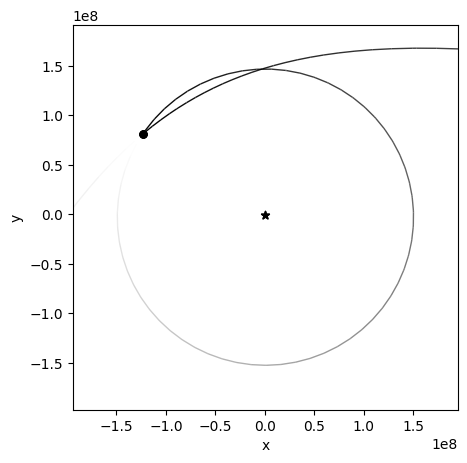

In [108]:
fig = rb.OrbitPlot(sim)

### Integracion hacia atras

In [109]:
hora = 3600
dia = 86400
t_end = 90*dia
print("tiempo de integracion: ", t_end)

N = 100
times = np.linspace(0, t_end, N)

state_v = np.zeros((N, 6))
earth = np.zeros((N, 3))
for i,time in enumerate(times):
    sim.integrate(-time)
    sim.move_to_hel()

    state_v[i] = sim.particles["Test"].xyz + sim.particles["Test"].vxyz 
    earth[i] = sim.particles["earth"].xyz

tiempo de integracion:  7776000


In [110]:
sun = sim.particles["sun"].xyz
x = state_v[:,0]
y = state_v[:,1]
# Gráfico base
fig = go.Figure(
    data=[
        # Órbita completa
        go.Scatter(x=x, y=y, mode="lines", line=dict(width=2, color="blue")),
        
        # Punto que se va a mover (inicialmente en x[0], y[0])
        go.Scatter(x=[x[0]], y=[y[0]], mode="markers", marker=dict(color="red", size=10)),

        # Tierra (estática)
        go.Scatter(x=[earth[0][0]], y=[earth[0][1]], mode="markers", marker=dict(color="blue", size=10)),

        # Sol (estático)
        #go.Scatter(x=[sun[0]], y=[sun[1]], mode="markers", marker=dict(color="yellow", size=10))
    ]
)

# Botón de reproducción
fig.update_layout(
    width=600, height=450,
    title_text=f"Background integration {t_end/day} days, vx = {vx} km/s", title_x=0.5,
    updatemenus=[dict(
        type="buttons",
        buttons=[
            dict(
                label="Play",
                method="animate",
                args=[None, {
                    "frame": {"duration": 50, "redraw": False},
                    "fromcurrent": True,
                    "transition": {"duration": 0}
                }]
            )
        ]
    )]
)

# Animación: solo se actualiza la traza del punto rojo (índice 1)
frames = [go.Frame(
    data=[
        go.Scatter(x=[x[k]], y=[y[k]], mode="markers", marker=dict(color="red", size=10))
    ],
    traces=[1]  # Asegura que sea el índice correcto del punto animado
) for k in range(len(x))]

fig.update(frames=frames)
fig.show()


Cambiando la velocidad, una menor a la velocidad de escape de la tierra

In [111]:
lon_test = 0 
lat_test = 0
alt_test = 0
date = meteor["Peak Brightness Date/Time (UT)"]
print("Date: ", date)

r_test = Geo2Rec(lon_test, lat_test, alt_test)
r_eclip = Geo2Eclip(lon_test, lat_test, alt_test, date=date, frame='ITRF93') #en km

t_sideral = 86164.09053083288 
w_earth = 2 * np.pi / t_sideral 
omega = np.array([0,0,w_earth]) #rad/s

vx = 12
vy = 0
vz = 0

v = np.array([vx, vy, vz])  
r = Geo2Rec(lon=lon_test, lat=lat_test, alt=alt_test)
v_E = (v + spy.vcrss(omega, r))

et = spy.utc2et(date)
mx = spy.pxform('ITRF93', 'ECLIPJ2000', et)
v_eclip = spy.mxv(mx, v_E)

r_eclip, v_eclip

Date:  2013-02-15 03:20:33


(array([-6152.98879348, -1537.89525336,   675.45065347]),
 array([-11.45391741,  -3.30516596,   1.44912836]))

In [112]:
rb.horizons.SSL_CONTEXT = 'unverified'

AU = 149597870 #km
day = 86400

sim = rb.Simulation()
sim.units = 'km', 's', 'kg'
sim.integrator = "IAS15"

time = Time(date, format="iso")
print("Time TDB: ", time.tdb)
print("Time TDB JD: ", time.tdb.jd)

sim.add("Sun", hash="sun", date=f"JD{time.tdb.jd}")
sim.add("399", hash="earth", date=f"JD{time.tdb.jd}")

r_earth = np.array(sim.particles['earth'].xyz)
v_earth = np.array(sim.particles['earth'].vxyz)

r_asteroid = r_eclip  + r_earth 
v_asteroid = v_eclip + v_earth #así si es 

print("Position ECLIPJ200: ", r_asteroid/AU)
print("Velocity ECLIPJ200: ", (v_asteroid/AU)*day)

asteroid = sim.add(x=r_asteroid[0], y=r_asteroid[1], z=r_asteroid[2], 
                vx=v_asteroid[0], vy=v_asteroid[1], vz=v_asteroid[2], hash="Test")

Time TDB:  2013-02-15 03:21:40.185
Time TDB JD:  2456338.6400484387
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Position ECLIPJ200:  [-8.24035963e-01  5.43764311e-01 -6.04428440e-05]
Velocity ECLIPJ200:  [-0.01640118 -0.01631382  0.0008378 ]


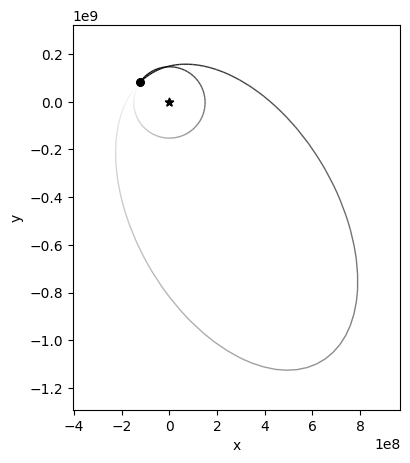

In [113]:
fig = rb.OrbitPlot(sim)

In [114]:
hora = 3600
dia = 86400
year = 3.154e+7
t_end = 90*dia
print("tiempo de integracion: ", t_end)

N = 100
times = np.linspace(0, t_end, N)

state_v = np.zeros((N, 6))
earth = np.zeros((N, 3))
for i,time in enumerate(times):
    sim.integrate(-time)
    sim.move_to_hel()
    state_v[i] = sim.particles["Test"].xyz + sim.particles["Test"].vxyz 
    earth[i] = sim.particles["earth"].xyz

tiempo de integracion:  7776000


In [115]:
sun = sim.particles["sun"].xyz
x = state_v[:,0]
y = state_v[:,1]
# Gráfico base
fig = go.Figure(
    data=[
        # Órbita completa
        go.Scatter(x=x, y=y, mode="lines", line=dict(width=2, color="blue")),
        
        # Punto que se va a mover (inicialmente en x[0], y[0])
        go.Scatter(x=[x[0]], y=[y[0]], mode="markers", marker=dict(color="red", size=10)),

        # Tierra (estática)
        go.Scatter(x=[earth[0][0]], y=[earth[0][1]], mode="markers", marker=dict(color="blue", size=10)),

        # Sol (estático)
        go.Scatter(x=[sun[0]], y=[sun[1]], mode="markers", marker=dict(color="yellow", size=10))
    ]
)

# Botón de reproducción
fig.update_layout(
    width=600, height=450,
    title_text=f"Background integration {t_end/day} days, vx = {vx} km/s", title_x=0.5,
    updatemenus=[dict(
        type="buttons",
        buttons=[
            dict(
                label="Play",
                method="animate",
                args=[None, {
                    "frame": {"duration": 50, "redraw": False},
                    "fromcurrent": True,
                    "transition": {"duration": 0}
                }]
            )
        ]
    )]
)

# Animación: solo se actualiza la traza del punto rojo (índice 1)
frames = [go.Frame(
    data=[
        go.Scatter(x=[x[k]], y=[y[k]], mode="markers", marker=dict(color="red", size=10))
    ],
    traces=[1]  # Asegura que sea el índice correcto del punto animado
) for k in range(len(x))]

fig.update(frames=frames)
fig.show()


### Integrando a Chely

In [116]:
indice = 376
meteor = fireballs.loc[indice]
meteor

Peak Brightness Date/Time (UT)         2013-02-15 03:20:33
Latitude (deg.)                                      54.8N
Longitude (deg.)                                     61.1E
Altitude (km)                                         23.3
Velocity (km/s)                                       18.6
vx                                                    12.8
vy                                                   -13.3
vz                                                    -2.4
Total Radiated Energy (J)                375000000000000.0
Calculated Total Impact Energy (kt)                  440.0
Name: 376, dtype: object

In [117]:
def change_coord(x):
    #funcion para trasformar el formato de coordenadas terrestres que da CNEOS
    if x[-1] == 'N' or x[-1] == 'E':
        new = float(x[:-1])
    elif x[-1] == 'S' or x[-1] == 'W':
        new = -float(x[:-1])
    return new    

#Parametros que obtenemos de los datos:
date = meteor['Peak Brightness Date/Time (UT)']
"""
lon = change_coord(meteor['Longitude (deg.)'])
lat = change_coord(meteor['Latitude (deg.)'])
alt = meteor['Altitude (km)']
vx = meteor['vx']
vy = meteor['vy']
vz = meteor['vz']
"""

lat = 55.07815
lon = 60.09285
alt = 178.4583
vx = meteor['vx']
vy = meteor['vy']
vz = meteor['vz']

date, lon, lat, alt, vx, vy, vz

('2013-02-15 03:20:33', 60.09285, 55.07815, 178.4583, 12.8, -13.3, -2.4)

In [118]:
r = Geo2Rec(lon, lat, alt)  #en km
print("Rectangular coodinates: ", r, mag(r))
r_eclip = Geo2Eclip(lon, lat, alt, date=date, frame='ITRF93') #en km
print("Ecliptic Cooridnates: ", r_eclip, mag(r_eclip))

v = np.array([vx, vy, vz])  #en km/s

t_sideral = 86164.09053083288 
w_earth = 2 * np.pi / t_sideral 
omega = np.array([0,0,w_earth]) #rad/s

v_E = v + spy.vcrss(omega, r) #km/s
#v_E, -v, mag(v_E), np.arccos((v@r_irtf)/(np.linalg.norm(v)*np.linalg.norm(r_irtf)))*180/np.pi

et = spy.utc2et(date)
mx = spy.pxform('ITRF93', 'ECLIPJ2000', et)
v_eclip = spy.mxv(mx, v_E)

Rectangular coodinates:  [1875.53000397 3260.70496115 5352.69238821] 6542.256907388374
Ecliptic Cooridnates:  [ -943.64333111 -1209.71732415  6359.81498957] 6542.256907388374


In [119]:
rb.horizons.SSL_CONTEXT = 'unverified'

AU = 149597870 #km
day = 86400

sim = rb.Simulation()
sim.units = 'km', 's', 'kg'
sim.integrator = "IAS15"
sim.dt = -86400

time = Time(date, format="iso")
print("Time TDB: ", time.tdb)
print("Time TDB JD: ", time.tdb.jd)

for i in ["Sun", "199", "299", "399", "499", "599", "699", "799", "899"]:
    sim.add(i, hash=f"{i}", date=f"JD{time.tdb.jd}")

#sim.add("Sun", hash="sun", date=f"JD2456338.639279")
#sim.add("399", hash="earth", date=f"JD2456338.639279")

r_earth = np.array(sim.particles["399"].xyz)
v_earth = np.array(sim.particles["399"].vxyz)

r_asteroid = r_eclip + r_earth 
v_asteroid = v_eclip + v_earth #así si es 

print("Position ECLIPJ200: ", r_asteroid/AU)
print("Velocity ECLIPJ200: ", (v_asteroid/AU)*day)

asteroid = sim.add(x=r_asteroid[0], y=r_asteroid[1], z=r_asteroid[2], 
                vx=v_asteroid[0], vy=v_asteroid[1], vz=v_asteroid[2], hash="Chely")

Time TDB:  2013-02-15 03:21:40.185
Time TDB JD:  2456338.6400484387
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '199'... 
Found: Mercury (199) 
Searching NASA Horizons for '299'... 
Found: Venus (299) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '499'... 
Found: Mars (499) 
Searching NASA Horizons for '599'... 
Found: Jupiter (599) 
Searching NASA Horizons for '699'... 
Found: Saturn (699) 
Searching NASA Horizons for '799'... 
Found: Uranus (799) 
Searching NASA Horizons for '899'... 
Found: Neptune (899) 
Position ECLIPJ200:  [-8.24001140e-01  5.43766504e-01 -2.24452152e-05]
Velocity ECLIPJ200:  [-0.01878905 -0.00997567 -0.00341727]


### Comparando datos del profe: 

Projected impact site:
Lat. : 55.07815N
Lon. : 60.09285E
Alt. : 178.4583 m

La fecha de impacto es:
Julian Date = 2456338.639279

La dirección del bolido era:
Radiant:
Az.  : 105.8913
Alt. : 17.84583

Las coordenadas del asteroide en el momento del impacto relativas a ECLIPJ2000 son:
Position vector at impact time (Ecliptic J2000.0):

x , y, z (AU) = -8.2296109700e-01 5.4628609900e-01 2.6028354800e-05
vx, vy, vz (AU/day) = -1.7823720100e-02 -9.2681019800e-03 -3.4069700000e-03 
r (AU) = 9.8777197200e-01

In [120]:
deg = 180/np.pi
sim.move_to_hel()
chely = sim.particles["Chely"]
#earth = sim.particles[1]
asteroid_statev = chely.xyz + chely.vxyz
#o_e = earth.orbit()
o = chely.orbit()
orbit_elements = [o.a/AU, o.e, o.inc*deg, o.Omega*deg, o.omega*deg, o.f] 
#orbit_elements_e = [o_e.a/AU, o_e.e, o_e.inc*deg, o_e.Omega*deg, o_e.omega*deg, o.f] 
print(f"Elementos orbitales instantaneos chely: ")   
print(f"a={orbit_elements[0]}, e={orbit_elements[1]}, i={orbit_elements[2]}, Omega={np.mod(orbit_elements[3], 360)}, omega={orbit_elements[4]}, f={orbit_elements[5]}")  

Elementos orbitales instantaneos chely: 
a=2.1779000741790506, e=0.6750066810446073, i=10.36895126812765, Omega=326.5715895442775, omega=107.32131635875054, f=1.268609126742783


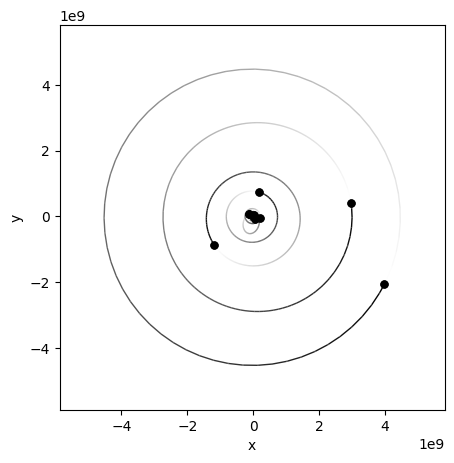

In [121]:
fig = rb.OrbitPlot(sim)

In [122]:
hora = 3600
deg = 180/np.pi
AU = 149597870 #km
a = 1.73*AU
mu = 1.98847e30*sim.G
periodo_orb = 2*np.pi*np.sqrt(a**3/mu)

t_end = 4*periodo_orb
#t_end = 24*hora
print("tiempo de integracion: ", t_end)

N = 10
times = np.linspace(0, t_end, N)

asteroid_statev = np.zeros((N, 6))
orbital_elements = np.zeros((N, 6))
for i,time in enumerate(times):
    sim.integrate(-time)
    sim.move_to_hel()
    chely = sim.particles["Chely"]
    asteroid_statev[i] = chely.xyz + chely.vxyz 

    o = chely.orbit()
    orbital_elements[i] = [o.a/AU, o.e, o.inc*deg, o.Omega*deg, o.omega*deg, o.f]

tiempo de integracion:  287238006.36966944


In [123]:
for element in orbital_elements:
    print(f"Elementos orbitales osculantes en tiempo {time} s")   
    print(f"a={element[0]}, e={element[1]}, i={element[2]}, Omega={np.mod(element[3], 360)}, omega={element[4]}, f={element[5]}") 

Elementos orbitales osculantes en tiempo 287238006.36966944 s
a=2.1779000741790506, e=0.6750066810446073, i=10.36895126812765, Omega=326.5715895442775, omega=107.32131635875054, f=1.268609126742783
Elementos orbitales osculantes en tiempo 287238006.36966944 s
a=1.72321971897412, e=0.5637709757224943, i=4.184073816973194, Omega=326.42384770798185, omega=109.53216434184405, f=3.37487798840756
Elementos orbitales osculantes en tiempo 287238006.36966944 s
a=1.7289318649783012, e=0.5623894385177998, i=4.184080730239613, Omega=326.5599889490508, omega=109.63236328547372, f=2.16328621640592
Elementos orbitales osculantes en tiempo 287238006.36966944 s
a=1.7159139302143032, e=0.5655230874646929, i=4.19068387876131, Omega=326.4663680306599, omega=109.70546319790851, f=3.634835987205273
Elementos orbitales osculantes en tiempo 287238006.36966944 s
a=1.7193093562822293, e=0.563079068023733, i=4.191640817505135, Omega=326.3925000819565, omega=109.47305032144615, f=2.5790396586103626
Elementos orbi